<h1 style="text-align: center; color: purple;">Phase 2: AtliQo Bank Credit Card Project</h1>

<h2 style="text-align: center; color: purple;">A/B testing for new Credit Card</h2>

#### Business Analysis and launch of new Credit Card: Targeting Untapped Market

#### Insights specific to customers with age group of 18 - 25:
1. People in the 18–25 age group account for approximately 25% of the customer base in the dataset.
2. The average annual income for this group is below 50k.
3. They do not have much credit history, which is reflected in their credit score and credit limit.
4. The usage of credit cards as a payment type is relatively low compared to other groups.
5. The average transaction value for credit card payments is also lower in this age group compared to others.
6. The top three shopping product categories are Electronics, Fashion & Apparel, and Beauty & Personal Care.

<div style="text-align:center;">

  <!-- Top Row -->
  <img src="../Phase1_Find_Target_Market/data_visualization/distribution_of_age_groups.png"
       style="width:40%; height:420px; object-fit:contain; vertical-align:middle;">
  <img src="../Phase1_Find_Target_Market/data_visualization/product_category_and_platform_count_across_age_groups.png"
       style="width:55%; height:420px; object-fit:contain; vertical-align:middle;">

  <br><br>

  <!-- Bottom Row -->
  <img src="../Phase1_Find_Target_Market/data_visualization/average_financial_metrics_by_age_group.png"
       style="width:65%; height:420px; object-fit:contain; vertical-align:middle;">
  <img src="../Phase1_Find_Target_Market/data_visualization/payment_type_distribution_across_age_groups.png"
       style="width:30%; height:420px; object-fit:contain; vertical-align:middle;">

</div>

<h2 style="text-align: center; color: darkorange;">1. Pre-Campaign (Campaign Planning)</h2>

We want to do a trial run for our new credit card. For this, we need to figure out how many customers we need for our A/B testing. We will form a control group and a test group. For both of these groups, we can determine the number of customers required based on the statistical power and effect size that we agree upon after discussing with the business team. We will use:

In [33]:
#import required libraries
import statsmodels.stats.api as sms
import statsmodels.api as sm
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns

In [34]:
alpha = 0.05
power = 0.8
effect_size=0.2

sms.tt_ind_solve_power(effect_size=0.2, alpha=alpha, power=power, ratio=1, alternative='two-sided')

393.40569300025237

For an effect size of 0.2, we need 393 customers. We have to keep in mind budgeting restrictions while running this campaign; hence, let us run this for different effect sizes and discuss with the business team to find out which sample size would be optimal.

#### **1.1 Calculate the required sample size for different effect sizes**

In [35]:
effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 1]  #  standard deviations greater than control group

for effect_size in effect_sizes:
    sample_size = sms.tt_ind_solve_power(effect_size=effect_size, alpha=alpha, power=power, ratio=1, alternative='two-sided')
    print(f"Effect Size: {effect_size}, Required Sample Size: {int(sample_size)} customers")

Effect Size: 0.1, Required Sample Size: 1570 customers
Effect Size: 0.2, Required Sample Size: 393 customers
Effect Size: 0.3, Required Sample Size: 175 customers
Effect Size: 0.4, Required Sample Size: 99 customers
Effect Size: 0.5, Required Sample Size: 63 customers
Effect Size: 1, Required Sample Size: 16 customers


Based on business requirements, the test should be capable of detecting a minimum 0.4 standard deviation difference between the control and test groups. For an effect size of 0.4, we need 100 customers, and after discussing with the business team, 100 customers is acceptable in terms of their budgeting constraints for this trial run.

#### **1.2 Forming control and test groups**

1. We have identified approximately 246 customers within the age group of 18 to 25. From this pool, we will select 100 customers for the initial campaign launch.
2. The campaign is launched for 100 customers, as determined by the effect size calculation and considering budgeting constraints, and will run for a duration of 2 months.
3. We achieved a conversion rate of ~40% (i.e., 40 out of 100 customers in the test group started using the credit card).
4. To maintain a similar sample size, a control group consisting of 40 customers will be created. Importantly, this control group will be completely exclusive of the initial 100 customers used as the test group.
5. So now, we have 40 customers in each of the control and test groups.

<h2 style="text-align: center; color: darkorange;">2. Execute Campaign (Support Campaign Launch)</h2>

1. At the end of the 2-month campaign period (from 09-10-23 to 11-10-23), we obtained daily data showing the average transaction amounts made by the entire group of 40 customers in both the control and test groups, using the existing and newly launched credit cards, respectively.
2. The key performance indicator (KPI) for this A/B test is to enhance the average transaction amount facilitated by the new card.

<h2 style="text-align: center; color: darkorange;">3. Post-Campaign Data Collection</h2>

#### **3.1 Load campaign results data**

In [36]:
df = pd.read_csv('data/avg_transactions_after_campaign.csv')

In [37]:
df.head(5)

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,259.83,277.32
1,2023-09-11,191.27,248.68
2,2023-09-12,212.41,286.61
3,2023-09-13,214.92,214.85
4,2023-09-14,158.55,344.08


In [38]:
df.shape

(62, 3)

In [39]:
df.shape[0]

62

#### **3.2 Distribution of average transaction amounts in both groups**

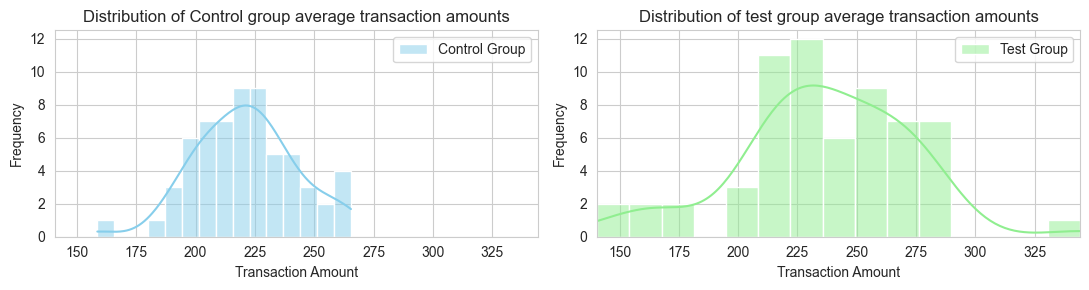

In [40]:
sns.set_style("whitegrid")

# Common X-axis range
xmin = min(df['control_group_avg_tran'].min(), df['test_group_avg_tran'].min())
xmax = max(df['control_group_avg_tran'].max(), df['test_group_avg_tran'].max())

bins = 15

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

# Control group
sns.histplot(df['control_group_avg_tran'],bins=bins,kde=True,color='skyblue',label='Control Group',ax=ax1)
ax1.set_xlim(xmin, xmax)
ax1.set_ylim(0, 12.5)   # ✅ FIXED Y-AXIS
ax1.set_xlabel('Transaction Amount')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Control group average transaction amounts')
ax1.legend()

# Test group
sns.histplot(df['test_group_avg_tran'],bins=bins,kde=True,color='lightgreen',label='Test Group',ax=ax2)
ax2.set_xlim(xmin, xmax)
ax2.set_ylim(0, 12.5)   # ✅ FIXED Y-AXIS
ax2.set_xlabel('Transaction Amount')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of test group average transaction amounts')
ax2.legend()

plt.tight_layout()
plt.savefig("data_visualization/Average_transaction_amounts_in_both_groups.png",dpi=300,bbox_inches="tight")
plt.show()

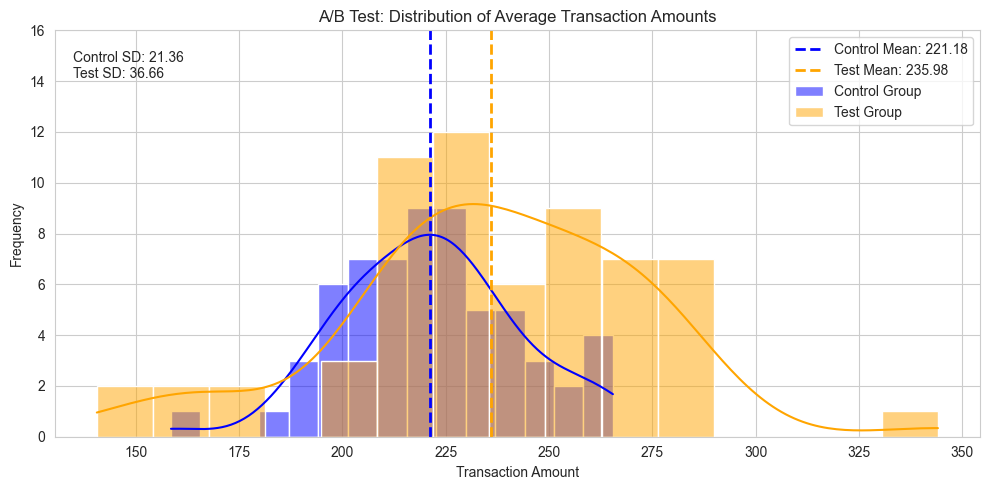

In [41]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 5))

# Data
control = df['control_group_avg_tran']
test = df['test_group_avg_tran']

# Plot distributions (frequency instead of density)
sns.histplot(control,kde=True,color='blue',label='Control Group',alpha=0.5,bins=15)
sns.histplot(test,kde=True,color='orange',label='Test Group',alpha=0.5,bins=15)

# Mean and Std
control_mean = control.mean()
test_mean = test.mean()

control_std = control.std()
test_std = test.std()

# Mean lines (thicker for visibility)
plt.axvline(control_mean, color='blue', linestyle='--', linewidth=2,label=f'Control Mean: {control_mean:.2f}')
plt.axvline(test_mean, color='orange', linestyle='--', linewidth=2,label=f'Test Mean: {test_mean:.2f}')

# SD text (cleaner instead of extra shading)
plt.text(0.02, 0.95,f'Control SD: {control_std:.2f}\nTest SD: {test_std:.2f}',transform=plt.gca().transAxes,fontsize=10,verticalalignment='top')

# Axis settings
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.title("A/B Test: Distribution of Average Transaction Amounts")

# 🔥 Fix Y-axis to match separate plots
plt.ylim(0, 16)
plt.legend()
plt.tight_layout()

# Save
plt.savefig("data_visualization/AB_test_distribution_of_average_transaction_amounts.png",dpi=300,bbox_inches="tight")
plt.show()

In [42]:
df[df['control_group_avg_tran'] > df['test_group_avg_tran']].head()

,campaign_date,control_group_avg_tran,test_group_avg_tran
3,2023-09-13,214.92,214.85
8,2023-09-18,265.13,212.60
9,2023-09-19,232.88,207.63
16,2023-09-26,222.95,213.30
22,2023-10-02,238.39,203.10


In [43]:
df[df['control_group_avg_tran'] > df['test_group_avg_tran']].shape

(18, 3)

In [44]:
((df['control_group_avg_tran'] > df['test_group_avg_tran']).mean()).round(4)

np.float64(0.2903)

In [45]:
df[df['control_group_avg_tran'] < df['test_group_avg_tran']].head()

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,259.83,277.32
1,2023-09-11,191.27,248.68
2,2023-09-12,212.41,286.61
4,2023-09-14,158.55,344.08
5,2023-09-15,262.63,266.86


In [46]:
df[df['control_group_avg_tran'] < df['test_group_avg_tran']].shape

(44, 3)

In [47]:
((df['control_group_avg_tran'] < df['test_group_avg_tran']).mean()).round(4)

np.float64(0.7097)

<h2 style="text-align: center; color: darkorange;">4. Hypothesis Testing & Decision Making</h2>

**Null Hypothesis:** The average transaction amount of the test group is less than or equal to that of the control group.

**Alternative Hypothesis:** The average transaction amount of the test group is greater than that of the control group.

#### **4.1 Perform Hypothesis Testing using Two Sample Z-test**

In [48]:
control_mean = df["control_group_avg_tran"].mean().round(4)
control_std = df["control_group_avg_tran"].std().round(4)
control_mean, control_std

(np.float64(221.1752), np.float64(21.3592))

In [49]:
test_mean = df["test_group_avg_tran"].mean().round(4)
test_std = df["test_group_avg_tran"].std().round(4)
test_mean, test_std

(np.float64(235.9835), np.float64(36.6581))

In [50]:
sample_size = df.shape[0]
sample_size

62

#### **4.2 Test using Rejection Region (i.e. Critical Z Value)**

In [51]:
a = (control_std**2/sample_size)
b = (test_std**2/sample_size)

Z_score = (test_mean-control_mean)/np.sqrt(a+b)
Z_score.round(4)

np.float64(2.7483)

In [52]:
# For a significance level of 5% (0.05) in a right-tailed test, the critical Z-value is approximately 1.645
critical_z_value = st.norm.ppf(1 - alpha)  # Right-tailed test at 5% significance level
critical_z_value.round(4)

np.float64(1.6449)

In [53]:
Z_score > critical_z_value

np.True_

1. Since the Z-score is higher than the critical Z-value, we can reject the null hypothesis.
2. Based on hypothesis testing, the average transaction amount for customers who used the new credit card is significantly higher than that of customers using the existing credit card in the 18–25 age group.

#### **4.3 Test Using p-Value**

In [54]:
# Calculate the p-value corresponding to z score for a right-tailed test
p_value = 1 - st.norm.cdf(Z_score)
p_value.round(4)

np.float64(0.003)

In [55]:
p_value < alpha # p value is less than significance level of 5% (or 0.05 for absolute value)

np.True_

Since the p-value is less than the significance level (i.e., alpha), we can reject the null hypothesis.

#### **4.4 Using Ready Made API call**

**We will now use the stats module from statsmodels to perform the Z-test:**

1. The order of the input groups in `sm.stats.ztest(test_data, control_data)` determines how the difference in means is calculated. Therefore, it must be aligned with the direction of the alternative hypothesis to ensure correct interpretation of the results.
2. When you pass the test group data first, the z-test module assumes the alternative hypothesis that the mean of the test group is greater than the mean of the control group. Conversely, if you switch the order, the module assumes that the control group average is greater than that of the test group.
3. In this case, we will use the order sm.stats.ztest(test_group_data, control_group_data) based on our alternative hypothesis defined above.
4. By default, the z-test module in statsmodels performs a two-tailed test. Since we are conducting a one-tailed test based on the direction of our alternative hypothesis, we need to set the "alternative" parameter accordingly.
5. In our case, based on the test direction, we will set the "alternative" parameter to "larger".

**How to choose the right "alternative" parameter:**
1. "two-sided": Used when you are interested in identifying deviations between control and test groups in either direction.
2. "larger": A one-tailed test used to check whether the first group has a significantly larger mean than the second group.
3. "smaller": A one-tailed test used to check whether the first group has a significantly smaller mean than the second group.

In [56]:
# Performing Z-test with above considerations
z_statistic, p_value = sm.stats.ztest( df['test_group_avg_tran'],df['control_group_avg_tran'],alternative = 'larger')
z_statistic.round(4), p_value.round(4)

(np.float64(2.7483), np.float64(0.003))

In [57]:
# Calculate the 95% confidence intervals (CI) for test group
test_group_CI = st.norm.interval(0.95, loc=test_mean, scale=test_std/np.sqrt(sample_size))
test_group_CI = tuple(round(x, 4) for x in test_group_CI)
test_group_CI

(np.float64(226.8587), np.float64(245.1083))

#### **4.5 Uplift calculation**

In [61]:
uplift = ((test_mean - control_mean) / control_mean) * 100
round(uplift, 2)

np.float64(6.7)

The new credit card resulted in an approximate 6.7% increase in average transaction amount compared to the existing card. This indicates a meaningful improvement in customer spending behavior and highlights the potential of the new card to drive higher revenue per transaction.

#### **4.6 Practical Significance (Observed Effect Size)**

In [72]:
pooled_std = np.sqrt((control_std**2 + test_std**2) / 2)
effect_size_actual = (test_mean - control_mean) / pooled_std

round(effect_size_actual, 4)

np.float64(0.4936)

The observed effect size is 0.49, which represents a moderate practical impact. This suggests that the increase in transaction amounts is not only statistically significant but also meaningful from a business perspective.

#### **4.7 Robustness Check**

In [75]:
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(df['test_group_avg_tran'], df['control_group_avg_tran'], equal_var=False)
t_stat.round(4), p_val.round(4)

(np.float64(2.7483), np.float64(0.0071))

The t-test results (p-value = 0.0071) align with the Z-test findings, as both tests lead to the rejection of the null hypothesis, indicating a statistically significant difference in average transaction amounts between the groups.